In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [13]:
# importing data
df = pd.read_csv('../datasets/ds_challenge_v2_1_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (54681, 11)


,id,city_name,signup_os,signup_channel,signup_date,bgc_date,vehicle_added_date,vehicle_make,vehicle_model,vehicle_year,first_completed_date
0,1,Strark,ios web,Paid,1/2/16,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Strark,windows,Paid,1/21/16,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Wrouver,windows,Organic,1/11/16,1/11/16,NaN,NaN,NaN,NaN,NaN
3,4,Berton,android web,Referral,1/29/16,2/3/16,2/3/16,Toyota,Corolla,2016.0,2/3/16
4,5,Strark,android web,Referral,1/10/16,1/25/16,1/26/16,Hyundai,Sonata,2016.0,NaN


In [7]:
df.dtypes

id                        int64
city_name                object
signup_os                object
signup_channel           object
signup_date              object
bgc_date                 object
vehicle_added_date       object
vehicle_make             object
vehicle_model            object
vehicle_year            float64
first_completed_date     object
dtype: object

In [ ]:
df['vehicle_year'] = df['vehicle_year'].astype('float64')
date_cols = ['signup_date','first_completed_date','bgc_date', 'vehicle_added_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format = '%m/%d/%y')

df['is_driver'] = ~ pd.isna(df['first_completed_date'])

In [ ]:
# time difference metrics
df['signup_to_bgc'] = (df['bgc_date'] - df['signup_date']) / datetime.timedelta(days = 1)
df['signup_to_vehicle_added'] = (df['vehicle_added_date'] - df['signup_date'])/datetime.timedelta(days = 1)
df['signup_to_first_completed'] = (df['first_completed_date'] - df['signup_date'])/datetime.timedelta(days = 1)
df['bgc_to_vehicle_added'] = (df['vehicle_added_date'] - df['bgc_date'])/datetime.timedelta(days = 1)
df['bgc_to_first_completed'] = (df['first_completed_date'] - df['bgc_date'])/datetime.timedelta(days = 1)
df['vehicle_added_to_first_completed'] = (df['first_completed_date'] - df['vehicle_added_date'])/datetime.timedelta(days = 1)

In [80]:
df.head()

,id,city_name,signup_os,signup_channel,signup_date,bgc_date,vehicle_added_date,vehicle_make,vehicle_model,vehicle_year,first_completed_date,is_driver,signup_to_bgc,signup_to_vehicle_added,signup_to_first_completed,bgc_to_vehicle_added,bgc_to_first_completed,vehicle_added_to_first_completed
0,1,Strark,ios web,Paid,2016-01-02,NaT,NaT,NaN,NaN,NaN,NaT,False,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Strark,windows,Paid,2016-01-21,NaT,NaT,NaN,NaN,NaN,NaT,False,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Wrouver,windows,Organic,2016-01-11,2016-01-11,NaT,NaN,NaN,NaN,NaT,False,0.0,NaN,NaN,NaN,NaN,NaN
3,4,Berton,android web,Referral,2016-01-29,2016-02-03,2016-02-03,Toyota,Corolla,2016.0,2016-02-03,True,5.0,5.0,5.0,0.0,0.0,0.0
4,5,Strark,android web,Referral,2016-01-10,2016-01-25,2016-01-26,Hyundai,Sonata,2016.0,NaT,False,15.0,16.0,NaN,1.0,NaN,NaN


In [24]:
# proportion of drivers
print(df['is_driver'].value_counts())
print('\n')
print(df['is_driver'].value_counts(normalize = True))

is_driver
False    48544
True      6137
Name: count, dtype: int64


is_driver
False    0.887767
True     0.112233
Name: proportion, dtype: float64


In [27]:
print(df['city_name'].value_counts())
print('')
print(df['city_name'].value_counts(normalize = True))

city_name
Strark     29557
Berton     20117
Wrouver     5007
Name: count, dtype: int64

city_name
Strark     0.540535
Berton     0.367897
Wrouver    0.091567
Name: proportion, dtype: float64


In [28]:
print(df['signup_os'].value_counts())
print('')
print(df['signup_os'].value_counts(normalize = True))

signup_os
ios web        16632
android web    14944
windows         6776
mac             5824
other           3648
Name: count, dtype: int64

signup_os
ios web        0.347775
android web    0.312479
windows        0.141686
mac            0.121780
other          0.076280
Name: proportion, dtype: float64


In [ ]:
# paid - through an ad
# referral - signup via current uber driver
# organic - signed up normally through app

print(df['signup_channel'].value_counts())
print('')
print(df['signup_channel'].value_counts(normalize = True))

signup_channel
Paid        23938
Referral    17316
Organic     13427
Name: count, dtype: int64

signup_channel
Paid        0.437775
Referral    0.316673
Organic     0.245551
Name: proportion, dtype: float64


In [30]:
df.columns

Index(['id', 'city_name', 'signup_os', 'signup_channel', 'signup_date',
       'bgc_date', 'vehicle_added_date', 'vehicle_make', 'vehicle_model',
       'vehicle_year', 'first_completed_date', 'is_driver'],
      dtype='object')

In [ ]:
print(df['signup_date'].min(), df['signup_date'].max())

print(df['first_completed_date'].min(), df['first_completed_date'].max())

# drivers who signed up in january.
# label is whether they drove prior to March 1 (in January or February)

2016-01-01 00:00:00 2016-01-30 00:00:00
2016-01-04 00:00:00 2016-02-29 00:00:00


## Date Distributions

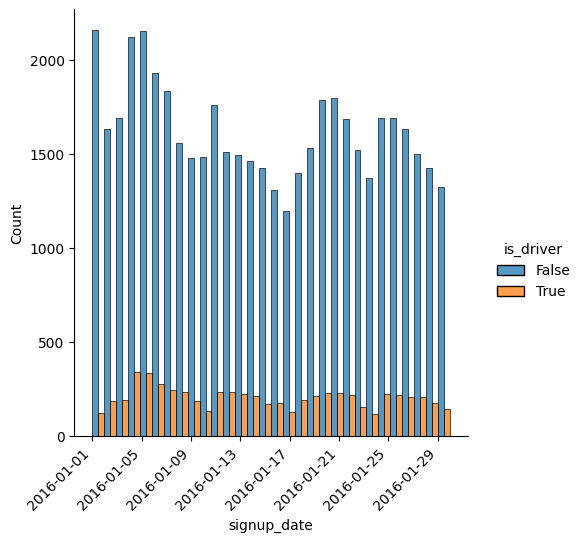

In [52]:
sns.displot(df, x = 'signup_date', bins = 30, hue = 'is_driver', multiple = 'dodge')
plt.xticks(rotation=45, horizontalalignment = 'right')
plt.show()

In [ ]:
df['bgc_date'].isnull().sum() # 21k ppl without a background check

np.int64(21785)

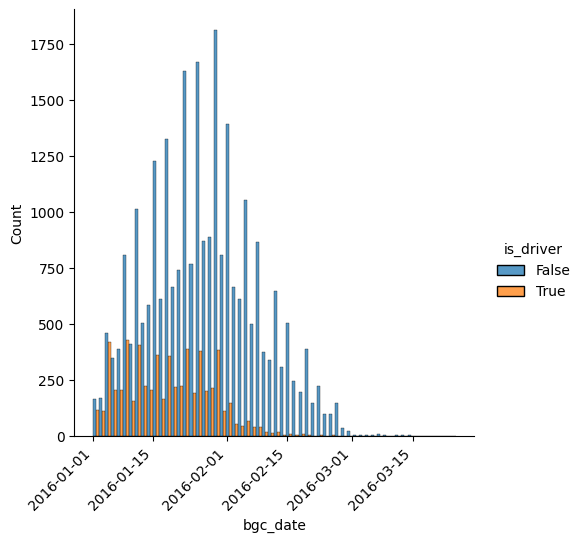

In [ ]:
sns.displot(df, x = 'bgc_date', bins = 60,  hue = 'is_driver', multiple = 'dodge')
plt.xticks(rotation=45, horizontalalignment = 'right')
plt.show()

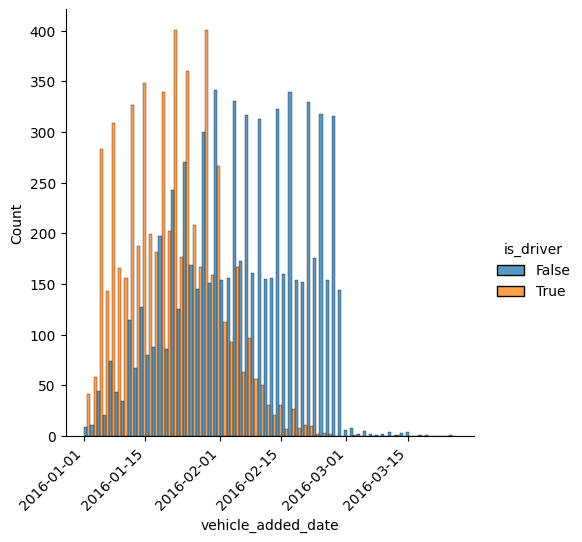

In [53]:
sns.displot(df, x = 'vehicle_added_date', bins = 60,  hue = 'is_driver', multiple = 'dodge')
plt.xticks(rotation=45, horizontalalignment = 'right')
plt.show()

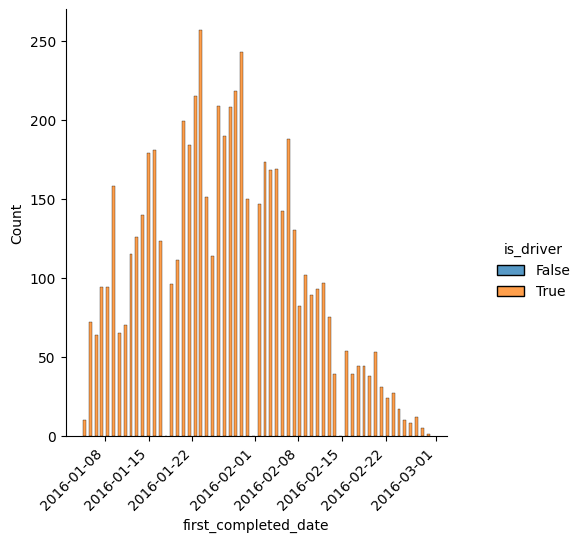

In [54]:
sns.displot(df, x = 'first_completed_date', bins = 60,  hue = 'is_driver', multiple = 'dodge')
plt.xticks(rotation=45, horizontalalignment = 'right')
plt.show()

In [63]:
df.dtypes

id                                            int64
city_name                                    object
signup_os                                    object
signup_channel                               object
signup_date                          datetime64[ns]
bgc_date                             datetime64[ns]
vehicle_added_date                   datetime64[ns]
vehicle_make                                 object
vehicle_model                                object
vehicle_year                                float64
first_completed_date                 datetime64[ns]
is_driver                                      bool
signup_to_bgc                       timedelta64[ns]
signup_to_vehicle_added             timedelta64[ns]
signup_to_first_completed           timedelta64[ns]
bgc_to_vehicle_added                timedelta64[ns]
bgc_to_first_completed              timedelta64[ns]
vehicle_added_to_first_completed    timedelta64[ns]
dtype: object

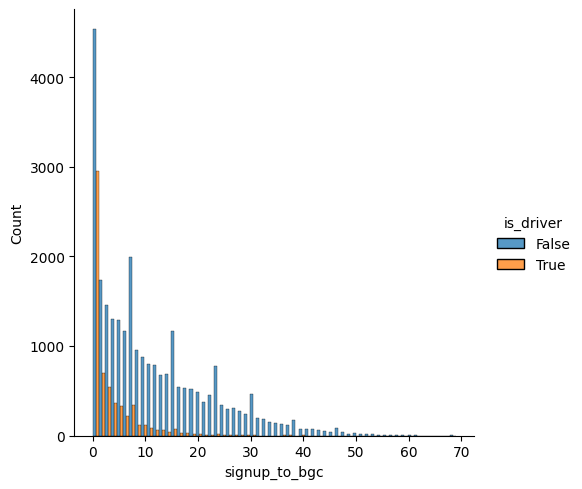

In [129]:
sns.displot(df, x = 'signup_to_bgc', bins = 60,  hue = 'is_driver', multiple = 'dodge')
plt.show()

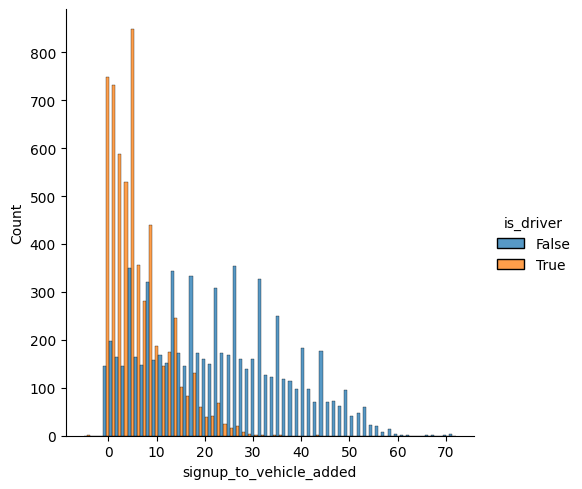

In [127]:
sns.displot(df, x = 'signup_to_vehicle_added', bins = 60,  hue = 'is_driver', multiple = 'dodge')
plt.show()

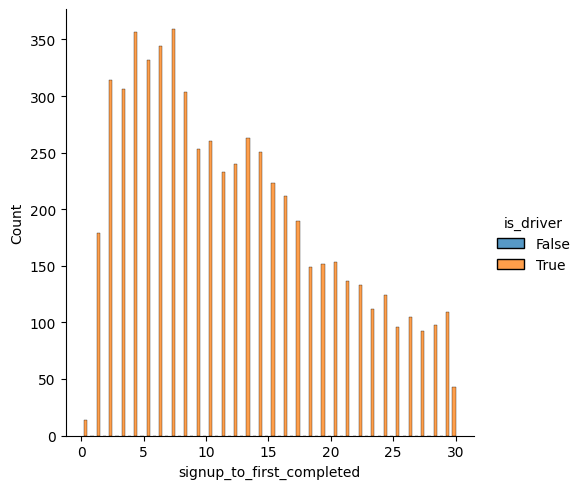

In [72]:
sns.displot(df, x = 'signup_to_first_completed', bins = 60,  hue = 'is_driver', multiple = 'dodge')
plt.show()

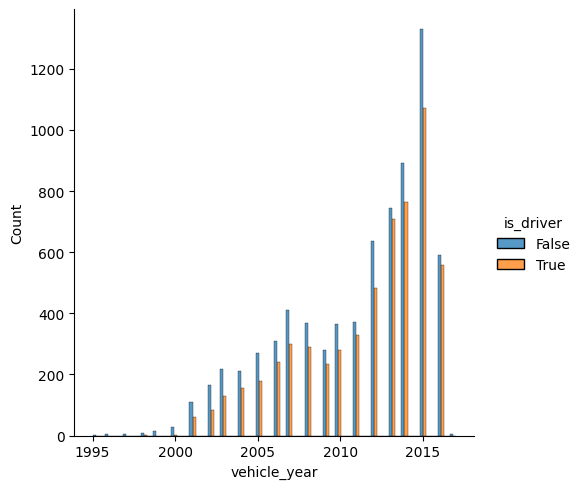

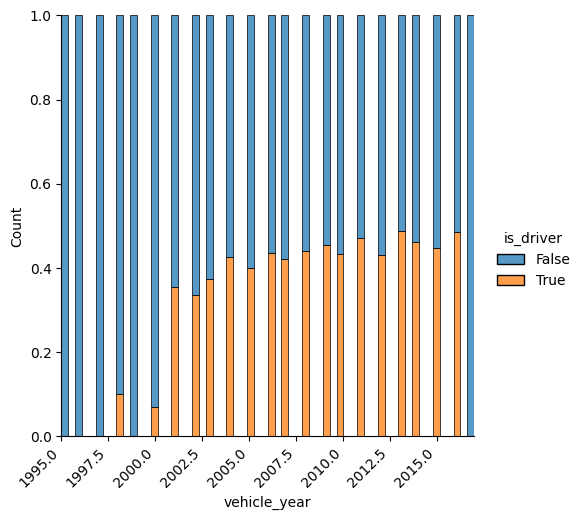

In [115]:
sns.displot(df[df['vehicle_year'] >= 1900], x = 'vehicle_year', bins = 60,  hue = 'is_driver', multiple = 'dodge')
plt.show()

sns.displot(df[df['vehicle_year'] >= 1900], x = 'vehicle_year', bins = 60,  hue = 'is_driver', multiple = 'fill')
plt.xticks(rotation=45, horizontalalignment = 'right')
plt.show()

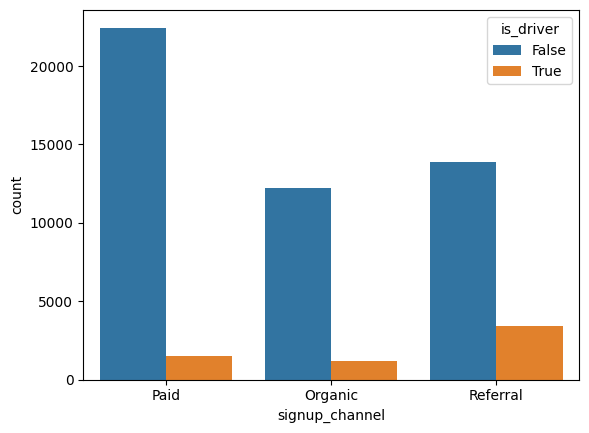

In [ ]:
sns.displot(df, x = 'signup_channel', hue = 'is_driver')
plt.show()

In [ ]:
0.063002/(0.063002+0.25) # ~20% of referrals end up driving.

0.20128305889419237

In [133]:
0.02/(0.41 + 0.02)

0.046511627906976744

In [134]:
0.02/(0.22 + 0.02)

0.08333333333333334

In [131]:
df[['signup_channel', 'is_driver']].value_counts(normalize = True)

signup_channel  is_driver
Paid            False        0.410673
Referral        False        0.253671
Organic         False        0.223423
Referral        True         0.063002
Paid            True         0.027103
Organic         True         0.022128
Name: proportion, dtype: float64

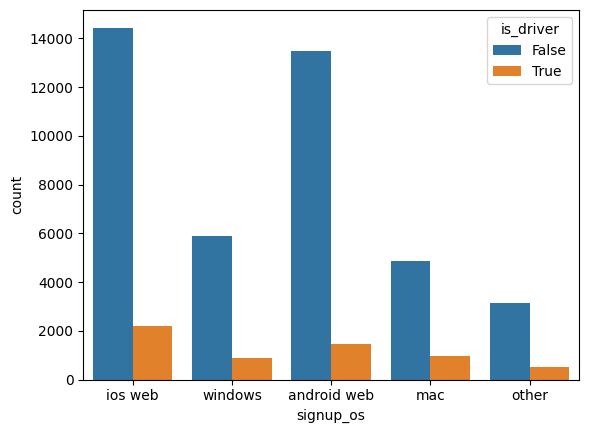

In [79]:
sns.countplot(df, x = 'signup_os', hue = 'is_driver')
plt.show()

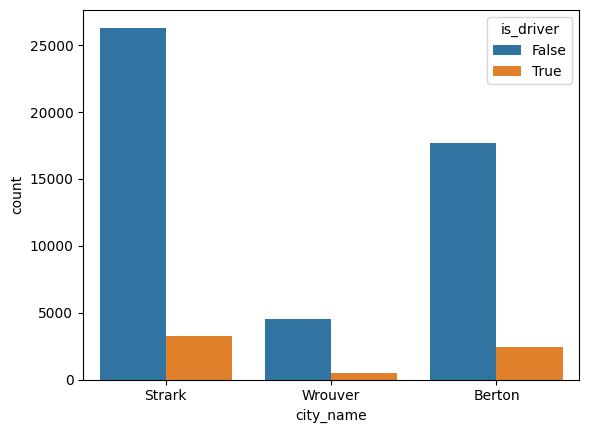

In [81]:
sns.countplot(df, x = 'city_name', hue = 'is_driver')
plt.show()

In [117]:
vehicle_make_cts = df[['vehicle_make', 'is_driver']].value_counts().reset_index()
vehicle_make_cts = pd.merge(vehicle_make_cts[vehicle_make_cts['is_driver'] == False],
                            vehicle_make_cts[vehicle_make_cts['is_driver'] == True], 
                            how ='outer', on = 'vehicle_make', suffixes = ('_false', '_true')).drop(['is_driver_false', 'is_driver_true'], axis = 1)
vehicle_make_cts.fillna(0, inplace = True)
vehicle_make_cts['total'] = vehicle_make_cts['count_false'] + vehicle_make_cts['count_true']
vehicle_make_cts['proportion_true'] = vehicle_make_cts['count_true']/vehicle_make_cts['total']

In [ ]:
# is driver proportion by make
vehicle_make_cts.sort_values(by = ['proportion_true', 'total'], ascending = False)

,vehicle_make,count_false,count_true,total,proportion_true
33,Oldsmobile,0.0,1.0,1.0,1.000000
29,Mercury,4.0,5.0,9.0,0.555556
40,Suzuki,6.0,6.0,12.0,0.500000
19,Isuzu,1.0,1.0,2.0,0.500000
26,Maserati,1.0,1.0,2.0,0.500000
38,Scion,85.0,79.0,164.0,0.481707
24,Lexus,174.0,161.0,335.0,0.480597
7,Buick,24.0,22.0,46.0,0.478261
42,Toyota,1684.0,1535.0,3219.0,0.476856
14,GMC,47.0,42.0,89.0,0.471910


In [119]:
vehicle_model_cts = df[['vehicle_model', 'is_driver']].value_counts().reset_index()
vehicle_model_cts = pd.merge(vehicle_model_cts[vehicle_model_cts['is_driver'] == False],
                            vehicle_model_cts[vehicle_model_cts['is_driver'] == True], 
                            how ='outer', on = 'vehicle_model', suffixes = ('_false', '_true')).drop(['is_driver_false', 'is_driver_true'], axis = 1)
vehicle_model_cts.fillna(0, inplace = True)
vehicle_model_cts['total'] = vehicle_model_cts['count_false'] + vehicle_model_cts['count_true']
vehicle_model_cts['proportion_true'] = vehicle_model_cts['count_true']/vehicle_model_cts['total']

In [123]:
# is driver proportion by make
vehicle_model_cts.sort_values(by = ['proportion_true', 'total'], ascending = True).head(50)

,vehicle_model,count_false,count_true,total,proportion_true
7,5-Sep,1.0,0.0,1.0,0.0
28,Aspen,1.0,0.0,1.0,0.0
37,Beetle,1.0,0.0,1.0,0.0
39,Blazer,1.0,0.0,1.0,0.0
47,CLK-Class,1.0,0.0,1.0,0.0
56,Cadenza,1.0,0.0,1.0,0.0
72,Classic,1.0,0.0,1.0,0.0
92,E-150 Cargo - WAV,1.0,0.0,1.0,0.0
114,F-350,1.0,0.0,1.0,0.0
117,FR-S,1.0,0.0,1.0,0.0


In [126]:
vehicle_model_cts[vehicle_model_cts['proportion_true']<0.2].sort_values('total', ascending = False)

,vehicle_model,count_false,count_true,total,proportion_true
33,Aveo,20.0,2.0,22.0,0.090909
138,GLK-Class,13.0,2.0,15.0,0.133333
271,S40,11.0,2.0,13.0,0.153846
207,Mirage,9.0,1.0,10.0,0.100000
221,Optimus Prime,7.0,1.0,8.0,0.125000
...,...,...,...,...,...
178,LX,1.0,0.0,1.0,0.000000
206,Metris,1.0,0.0,1.0,0.000000
209,Monterey,1.0,0.0,1.0,0.000000
211,Mountaineer,1.0,0.0,1.0,0.000000


In [135]:
df['signup_date'].dt.date.astype(int)

TypeError: int() argument must be a string, a bytes-like object or a real number, not 'datetime.date'